In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json

from hgnn.Modules_zinb import log_zinb_positive
from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from sklearn.preprocessing import MinMaxScaler

In [3]:
from examples.case_studies.PEA_STA_analysis import load_data

expression_data, methylation_data, labels = load_data()

In [4]:
len(labels)

210

In [5]:
def remove_all_nan_columns(data, remove_all_zeros=True):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])

    if remove_all_zeros:
        # 删除全是0的列。
        valid_cols = ~np.all(np.abs(data) < 1e-5, axis=0)
        data = data[:, valid_cols]
        print('After remove all zeros', data.shape[1])

    return data

In [6]:
expression_data_clean = remove_all_nan_columns(expression_data)
methylation_data_clean = remove_all_nan_columns(methylation_data)

Input #cols 141
After remove all nan 88
After remove all zeros 76
Input #cols 141
After remove all nan 78
After remove all zeros 77


Text(0.5, 1.0, 'methylation_data_clean')

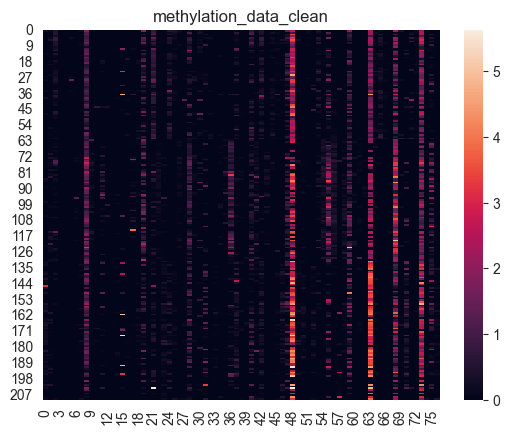

In [7]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

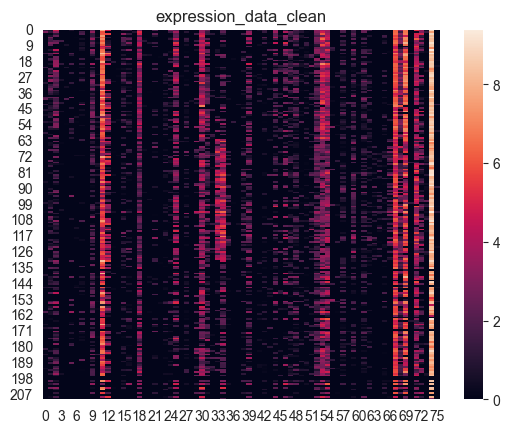

In [8]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [9]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(np.abs(data) > 1e-5)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [10]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [11]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((5536, 3), (5536,), (4440, 3), (4440,))

In [12]:
expression_edges.max(0), methylation_edges.max(0)

(array([209,  75,   0]), array([209, 152,   1]))

In [13]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [14]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [15]:
edges.shape, weights.shape

((9976, 3), (9976,))

In [16]:
weights.min(), weights.max()

(np.float64(0.001), np.float64(9.391))

In [17]:
np.any(np.abs(weights) < 1e-5)

np.False_

In [18]:
save_edges_and_weights('./data/PEA_STA', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [19]:
train_data = np.load('./data/PEA_STA/train_data.npz', allow_pickle=True)
test_data = np.load('./data/PEA_STA/test_data.npz', allow_pickle=True)

In [20]:
train_data['train_weight'].shape

(9976,)

In [21]:
np.any(np.any(train_data['train_weight'] < 1e-5))

np.False_

In [22]:
train_data['nums_type']

array([210, 153,   2])

In [23]:
!mkdir -p ./embeddings/hgnn/PEA_STA

In [24]:
# !python3 hgnn/main_torch_zinb.py --data PEA_STA --feature adj --loss zinb --iter 50 && mv ./*.npy ./embeddings/hgnn/PEA_STA

## Analysis

In [303]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from torch.optim import Adam
import torch.nn.functional as F
import torch
from hgnn.phasing import *

In [26]:
cell_embeddings = np.load('./embeddings/hgnn/PEA_STA/mymodel_0.npy', allow_pickle=True)
gene_embeddings = np.load('./embeddings/hgnn/PEA_STA/mymodel_1.npy', allow_pickle=True)
omic_embeddings = np.load('./embeddings/hgnn/PEA_STA/mymodel_2.npy', allow_pickle=True)


In [27]:
cell_embeddings.shape

(210, 64)

{'NMI': 0.7843258349084452,
 'ARI': 0.7833805665479604,
 'FMI': 0.8552699956034806}

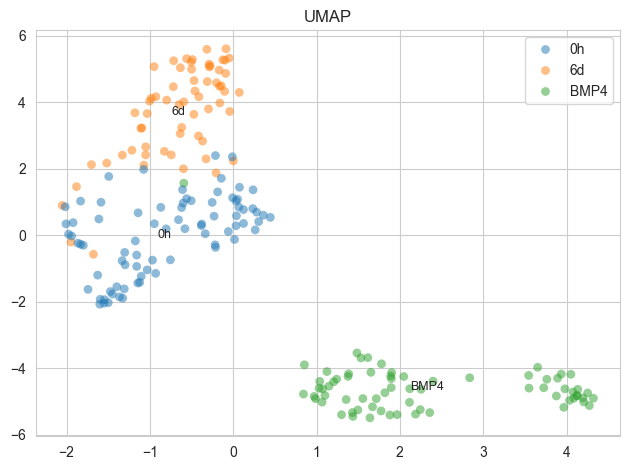

In [28]:
umap_visualize(cell_embeddings, labels)

## Phasing

In [240]:
G = torch.tensor(gene_embeddings, dtype=torch.float)
C = torch.tensor(cell_embeddings, dtype=torch.float)
O = torch.tensor(omic_embeddings, dtype=torch.float)
X_np = np.concatenate([expression_data_clean, methylation_data_clean], axis=1)
# X_np = MinMaxScaler().fit_transform(X_np)
X = torch.tensor(X_np, dtype=torch.float)

In [251]:
class PhasingModel(nn.Module):

    def __init__(self, embed_dim, num_cells, num_genes, activations, omics_offset):
        super().__init__()
        self.omics_offset = omics_offset
        self.activations = activations

        self.M = {} # d x d matrix
        self.Lambda = {} # scalar

        for parental in range(2):
            for omic in range(2):
                self.M[parental, omic] = nn.Sequential(
                    nn.Linear(embed_dim, embed_dim),
                    nn.ReLU(),
                    nn.Linear(embed_dim, embed_dim),
                )
                #nn.Parameter(torch.empty(embed_dim, embed_dim))
                self.Lambda[parental, omic] = nn.Parameter(torch.empty(1))

        self.A = {0: nn.Parameter(torch.empty(num_cells, omics_offset)),
                  1: nn.Parameter(torch.empty(num_cells, num_genes - omics_offset))}
        self.B = {0: nn.Parameter(torch.empty(num_cells, omics_offset)),
                  1: nn.Parameter(torch.empty(num_cells, num_genes - omics_offset))}

        for param in self.parameters():
            nn.init.normal_(param)

    def parameters(self, recurse: bool = True):
        yield from self.M.values()
        yield from self.A.values()
        yield from self.B.values()
        yield from self.Lambda.values()

    def forward(self, G, C, O):
        act0, act1 = self.activations
        G0, G1 = G[:self.omics_offset], G[self.omics_offset:]
        Xp0 = act0(self.M[0, 0](C) @ self.M[0, 0](G0 + self.Lambda[0, 0] * O[0]).T * self.A[0] + self.B[0])
        Xp1 = act1(self.M[0, 1](C) @ self.M[0, 1](G1 + self.Lambda[0, 1] * O[1]).T * self.A[1] + self.B[1])
        Xm0 = act0(self.M[1, 0](C) @ self.M[1, 0](G0 + self.Lambda[1, 0] * O[0]).T * self.A[0] + self.B[0])
        Xm1 = act1(self.M[1, 1](C) @ self.M[1, 1](G1 + self.Lambda[1, 1] * O[1]).T * self.A[1] + self.B[1])

        # Xp0 = act0(C @ self.M[0, 0] @ (G0 + self.Lambda[0, 0] * O[0]).T * self.A[0] + self.B[0])
        # Xp1 = act1(C @ self.M[0, 1] @ (G1 + self.Lambda[0, 1] * O[1]).T * self.A[1] + self.B[1])
        # Xm0 = act0(C @ self.M[1, 0] @ (G0 + self.Lambda[1, 0] * O[0]).T * self.A[0] + self.B[0])
        # Xm1 = act1(C @ self.M[1, 1] @ (G1 + self.Lambda[1, 1] * O[1]).T * self.A[1] + self.B[1])
        return Xp0, Xp1, Xm0, Xm1

    @torch.no_grad()
    def predict(self, G, C, O):
        res = self.forward(G, C, O)
        return [r.cpu().numpy() for r in res]

    def reconstruct(self, G, C, O):
        return self.forward(G, C, O)


In [307]:
epochs = 8000
embed_dim = C.shape[1]
# 超参，按需要调
alpha = 0.00001
k = 3
lr = 1e-2
omics_offset = expression_data_clean.shape[1]
num_cells = C.shape[0]
num_genes = G.shape[0]
embed_dim, omics_offset

(64, 76)

In [308]:
model = PhasingModel(embed_dim=embed_dim, num_cells=num_cells, num_genes=num_genes,
                     activations=[F.softplus, F.softplus], omics_offset=omics_offset)
optimizer = Adam(model.parameters(), lr=lr)
num_cells = X.shape[0]
cell_dataset = TensorDataset(C, X)
dataloader = DataLoader(cell_dataset, shuffle=True, batch_size=num_cells)
recon_loss = [F.mse_loss, F.mse_loss]
history, history_recon, history_reg = [], [], []

In [309]:
for epoch in range(epochs):
    epoch_loss, epoch_rec, epoch_reg = 0., 0., 0.
    for c_batch, x_batch in dataloader:
        c_batch, x_batch = c_batch.to(C.device), x_batch.to(C.device)

        xp0, xp1, xm0, xm1 = model(G, c_batch, O)
        x0_hat, x1_hat = xp0 + xm0, xp1 + xm1
        xp = torch.cat([xp0, xp1], dim=1)
        xm = torch.cat([xm0, xm1], dim=1)
        x0_batch, x1_batch = x_batch[:, :model.omics_offset], x_batch[:, model.omics_offset:]
        loss_recon = recon_loss[0](x0_hat, x0_batch) + recon_loss[1](x1_hat, x1_batch)

        lap0_batch = build_laplacian(x0_batch.cpu().numpy(), k=k).to(C.device)
        loss_regular0 = torch.trace(xp0.T @ lap0_batch @ xp0) + torch.trace(xm0.T @ lap0_batch @ xm0)
        lap1_batch = build_laplacian(x1_batch.cpu().numpy(), k=k).to(C.device)
        loss_regular1 = torch.trace(xp1.T @ lap1_batch @ xp1) + torch.trace(xm1.T @ lap1_batch @ xm1)
        loss_reg = loss_regular0 + loss_regular1

        loss = loss_recon + alpha * loss_reg
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_rec += loss_recon.item()
        epoch_reg += loss_reg.item()

    history.append(epoch_loss)
    history_recon.append(epoch_rec)
    history_reg.append(epoch_reg)
    if epoch % 100 == 0:
        print(f'Epoch {epoch:3d}  total={epoch_loss:.3f}  rec={epoch_rec:.3f}  reg={epoch_reg:.3f}')


Epoch   0  total=664.227  rec=642.577  reg=2165003.500
Epoch 100  total=3.929  rec=3.929  reg=1.648
Epoch 200  total=3.929  rec=3.929  reg=1.051
Epoch 300  total=3.929  rec=3.929  reg=0.712
Epoch 400  total=3.929  rec=3.929  reg=0.564
Epoch 500  total=3.929  rec=3.929  reg=0.379
Epoch 600  total=3.929  rec=3.929  reg=0.306
Epoch 700  total=3.929  rec=3.929  reg=0.240
Epoch 800  total=3.929  rec=3.929  reg=0.197
Epoch 900  total=3.929  rec=3.929  reg=0.167
Epoch 1000  total=3.929  rec=3.929  reg=0.138
Epoch 1100  total=3.929  rec=3.929  reg=0.119
Epoch 1200  total=3.929  rec=3.929  reg=0.113
Epoch 1300  total=3.929  rec=3.929  reg=0.096
Epoch 1400  total=3.929  rec=3.929  reg=0.102
Epoch 1500  total=3.929  rec=3.929  reg=0.288
Epoch 1600  total=3.754  rec=3.715  reg=3853.016
Epoch 1700  total=0.930  rec=0.893  reg=3789.809
Epoch 1800  total=0.849  rec=0.808  reg=4086.433
Epoch 1900  total=0.809  rec=0.767  reg=4197.282
Epoch 2000  total=0.781  rec=0.738  reg=4283.986
Epoch 2100  total=0

In [310]:
Xp0, Xp1, Xm0, Xm1 = model.predict(G, C, O)

In [311]:
np.all(Xp0 < 1), np.all(Xp1 < 1), np.all(Xm0 < 1), np.all(Xm1 < 1)

(np.False_, np.True_, np.False_, np.True_)

Text(0.5, 1.0, 'X1')

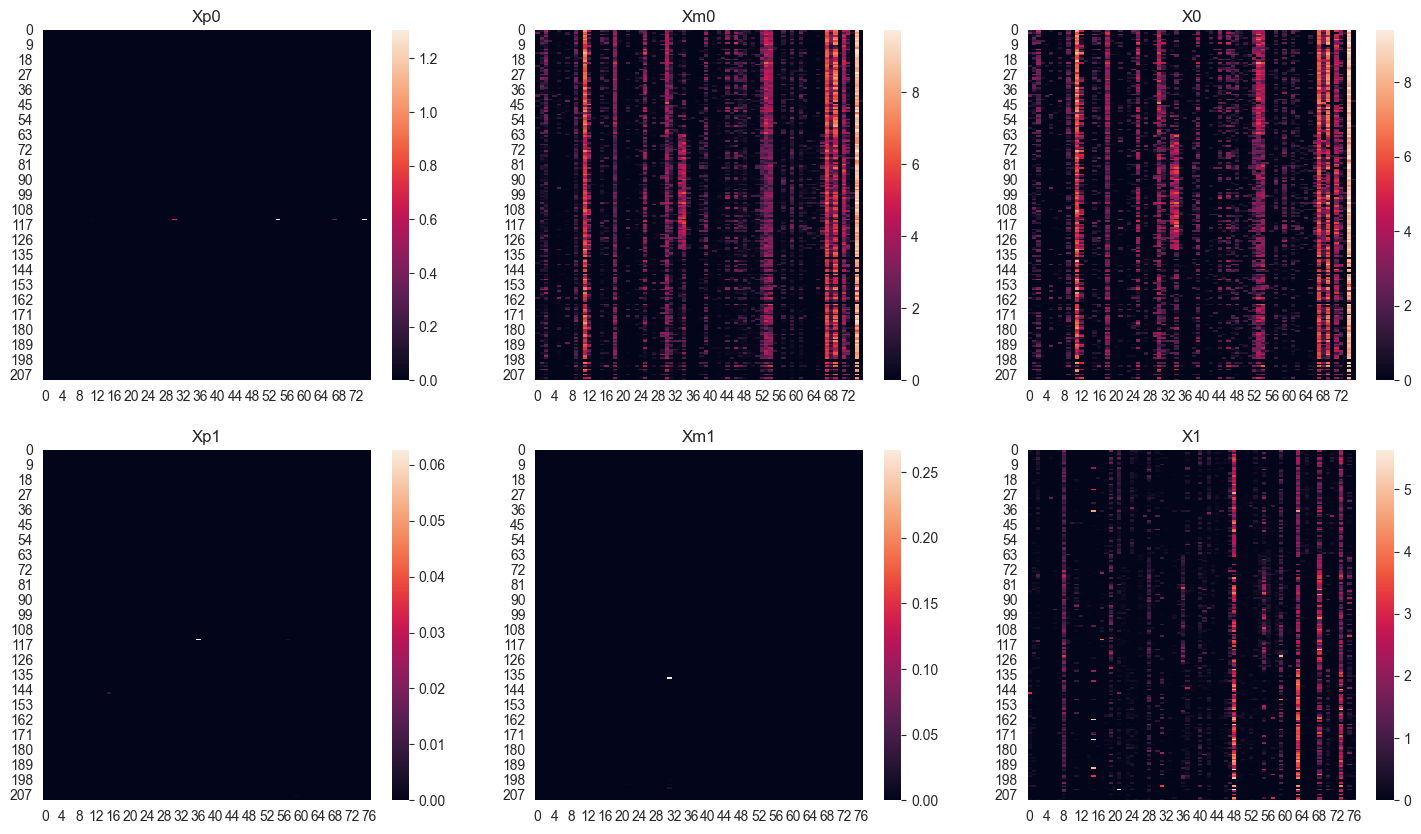

In [312]:
plt.figure(figsize=(18,10))
ax = plt.subplot(231)
sns.heatmap(Xp0,ax=ax)
plt.title('Xp0')
ax = plt.subplot(232)
sns.heatmap(Xm0,ax=ax)
plt.title('Xm0')
ax = plt.subplot(233)
sns.heatmap(expression_data_clean,ax=ax)
plt.title('X0')
ax = plt.subplot(234)
sns.heatmap(Xp1,ax=ax)
plt.title('Xp1')
ax = plt.subplot(235)
sns.heatmap(Xm1,ax=ax)
plt.title('Xm1')
ax = plt.subplot(236)
sns.heatmap(methylation_data_clean,ax=ax)
plt.title('X1')

In [281]:
expression_data_clean - (Xp0 + Xm0)

array([[ 6.05088154e-01, -3.70422658e-01,  1.34125129e+00, ...,
         3.92353154e-01,  1.02947965e+00, -3.87835462e-05],
       [ 1.63779502e+00,  2.74900548e-01,  1.25936059e+00, ...,
         1.14561692e+00,  1.10025140e+00, -7.03001490e-07],
       [-3.80386971e-03, -3.69748116e-01, -2.10247572e-01, ...,
        -4.15730476e-02,  8.40552216e-01, -4.10093664e-04],
       ...,
       [-1.11764134e-03, -3.21474485e-02, -6.21897876e-02, ...,
        -4.69229147e-02, -9.73384261e-01, -9.90106628e-07],
       [-6.71623126e-02, -5.34278152e-02,  8.11938295e-01, ...,
        -6.34108707e-02,  9.36489609e-01,  1.88874149e-02],
       [-1.05876930e-01, -1.20816588e-01, -4.39003527e-01, ...,
        -7.99905807e-02, -1.39340989e+00, -7.75079627e-07]],
      shape=(210, 76))

{'NMI': 0.21390374393851166,
 'ARI': 0.16482109414555457,
 'FMI': 0.490535326557467}

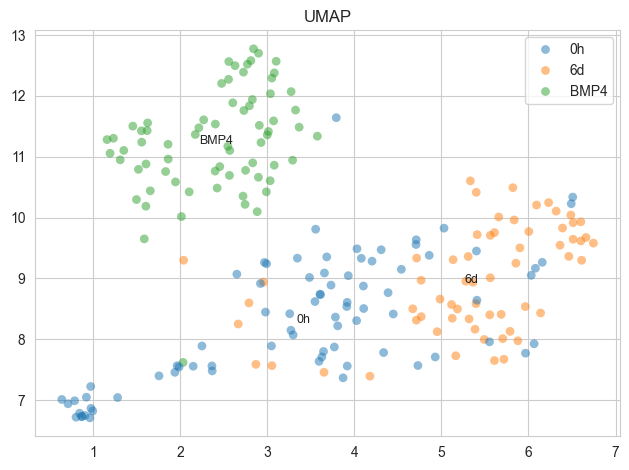

In [282]:
umap_visualize(X, labels)

{'NMI': 0.15202686620889552,
 'ARI': 0.15209328487118795,
 'FMI': 0.4392335920995291}

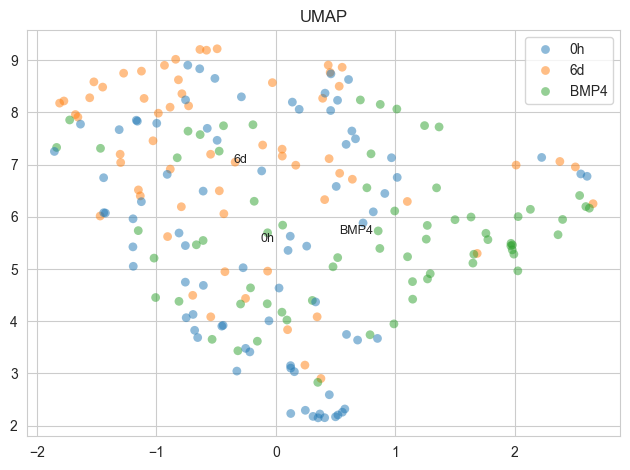

In [301]:
umap_visualize(Xp0, labels)

{'NMI': 0.13323553097888818,
 'ARI': 0.13714385621395656,
 'FMI': 0.4246445630949915}

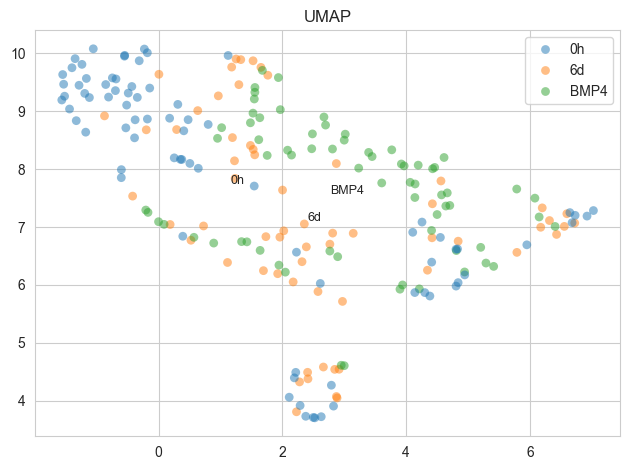

In [302]:
umap_visualize(Xp1, labels)

{'NMI': 0.08380749896409576,
 'ARI': 0.07569899451054407,
 'FMI': 0.4402133447296262}

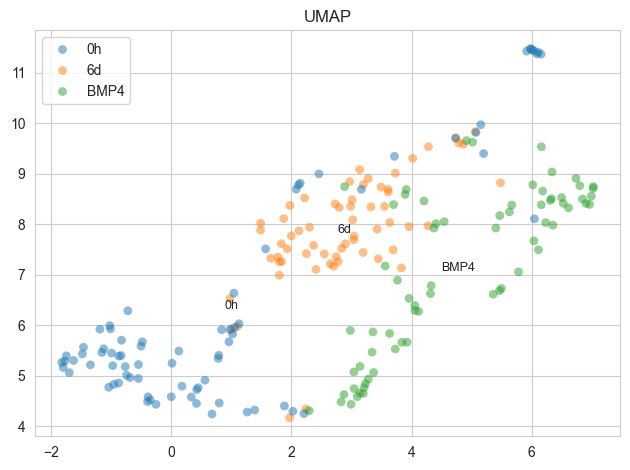

In [285]:
umap_visualize(Xm1, labels)

{'NMI': 0.1255179656246715,
 'ARI': 0.05541413717519956,
 'FMI': 0.4207868017591105}

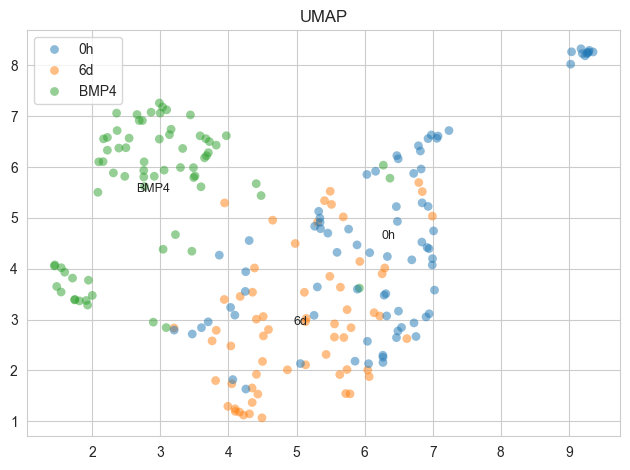

In [286]:
umap_visualize(Xm0, labels)